# 11 · Continuous-time Markov chains

In continuous time a Markov chain waits an exponential time in each state and then jumps; it is specified by a
generator Q of rates. This notebook computes the transition function P(t) = e^{Qt} (and why uniformisation is a
safer way), stationary laws and absorption times, estimates a generator from a machine's two-year event log,
and simulates chemical reaction networks and epidemics with Gillespie's algorithm.

**What you will learn**
- build generators and compute transition functions by exponentials and uniformisation
- estimate a generator from an event log, handling censoring
- analyse birth-death chains and absorption times
- simulate reaction networks by Gillespie's algorithm and tau-leaping

**Before you start:** notebooks 05-06 and 09  ·  **Time:** about 90 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg as sla
from engstoch import ctmc, models, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Generators and the transition function

In [2]:
m = models.machine()
c, Q = m["chain"], m["Q"]
print("generator Q (per hour), states", c.states, "\n", Q)
print("holding rates q_i:", c.rates, " -> mean sojourns (h):", np.round(1 / c.rates, 2))
print("jump chain:\n", np.round(c.jump_chain().P, 3))
for t in (1.0, 10.0, 100.0):
    P = c.transition_matrix(t); U = c.uniformisation(t)
    print(f"P({t:5.0f} h) from 'up': {np.round(P[0], 4).tolist()}  | uniformisation: {U['terms']} terms, error bound {U['bound']:.0e}, diff vs scipy {np.max(np.abs(P - sla.expm(Q * t))):.0e}")
print("stationary law:", c.stationary().round(4).tolist(), "= jump-chain law weighted by mean holding times:", c.stationary_via_jump_chain().round(4).tolist())

generator Q (per hour), states ['up', 'degraded', 'down'] 
 [[-0.07  0.05  0.02]
 [ 1.   -1.2   0.2 ]
 [ 0.5   0.   -0.5 ]]
holding rates q_i: [0.07 1.2  0.5 ]  -> mean sojourns (h): [14.29  0.83  2.  ]
jump chain:
 [[0.    0.714 0.286]
 [0.833 0.    0.167]
 [1.    0.    0.   ]]
P(    1 h) from 'up': [0.9536, 0.0282, 0.0182]  | uniformisation: 16 terms, error bound 3e-13, diff vs scipy 3e-15
P(   10 h) from 'up': [0.9108, 0.038, 0.0513]  | uniformisation: 44 terms, error bound 1e-12, diff vs scipy 3e-14
P(  100 h) from 'up': [0.9105, 0.0379, 0.0516]  | uniformisation: 206 terms, error bound 7e-13, diff vs scipy 3e-14
stationary law: [0.9105, 0.0379, 0.0516] = jump-chain law weighted by mean holding times: [0.9105, 0.0379, 0.0516]


P(t) solves Kolmogorov's equations P′ = QP = PQ, so P(t) = e^{Qt}. The matrix exponential is computed by
scaling and squaring with a Padé approximant; uniformisation writes P(t) as a Poisson mixture of powers of the
stochastic matrix I + Q/Λ - all terms non-negative, so there is no cancellation and the truncation error is
known in advance. The stationary law weights the jump chain's visit frequencies by the mean holding times.

## Estimating Q from an event log

In [3]:
log = pd.read_csv(datasets.path("machine_log.csv"), comment="#")
code_ = {s: i for i, s in enumerate(c.states)}
est = ctmc.estimate_generator(log.time_h.to_numpy(), log.state.map(code_).to_numpy(), 17520.0, 3)
print(f"{len(log)} events over two years; occupation hours:", est["occupation_time"].round(0).tolist())
print("estimated Q:\n", np.round(est["Q"], 4), "\nstandard errors:\n", np.round(est["std_error"], 4), "\ntrue Q:\n", Q)
soj = np.diff(np.r_[log.time_h.to_numpy(), 17520.0])
for s_ in c.states:
    x = soj[log.state.to_numpy() == s_][:-1] if s_ == "up" else soj[log.state.to_numpy() == s_]
    print(f"{s_:<9}: {len(x)} sojourns, mean {x.mean():6.2f} h, cv {x.std() / x.mean():.3f} (exponential: 1)")
print(f"\navailability: fraction of time not down {1 - est['occupation_time'][2] / 17520:.4f}; model {1 - c.stationary()[2]:.4f}")

2355 events over two years; occupation hours: [15927.0, 589.0, 1003.0]
estimated Q:
 [[-0.0701  0.049   0.021 ]
 [ 1.1182 -1.3252  0.207 ]
 [ 0.4555  0.     -0.4555]] 
standard errors:
 [[0.     0.0018 0.0011]
 [0.0436 0.     0.0187]
 [0.0213 0.     0.    ]] 
true Q:
 [[-0.07  0.05  0.02]
 [ 1.   -1.2   0.2 ]
 [ 0.5   0.   -0.5 ]]
up       : 1116 sojourns, mean  14.25 h, cv 0.994 (exponential: 1)
degraded : 781 sojourns, mean   0.75 h, cv 1.031 (exponential: 1)
down     : 457 sojourns, mean   2.20 h, cv 0.970 (exponential: 1)

availability: fraction of time not down 0.9427; model 0.9484


With a complete path the likelihood factorises and the MLE of each rate is the number of i → j transitions
divided by the total time spent in i - including the final, censored sojourn, which contributes time but no
transition. Dropping it, or treating it as complete, biases the up-state rates (slightly, here, because it is
one of a thousand). Sojourns with a coefficient of variation near 1 support the exponential assumption.

## Birth-death chains and absorption

In [4]:
K, lam, mu = 30, 0.8, 1.0
bd = ctmc.birth_death([lam] * K, [mu] * K)
rho = lam / mu
print("M/M/1/30 stationary law vs (1 - rho) rho^n / (1 - rho^31):", np.max(np.abs(bd["stationary"] - (1 - rho) * rho ** np.arange(K + 1) / (1 - rho ** (K + 1)))))
pop = ctmc.CTMC(np.array([[0, 0, 0, 0, 0], [1.0, -2.5, 1.5, 0, 0], [0, 2.0, -5.0, 3.0, 0], [0, 0, 3.0, -7.5, 4.5], [0, 0, 0, 4.0, -4.0]]))
ab = pop.absorption_times()
print("population with births 1.5 n and deaths n (cap 4): expected time to extinction from n = 1..4:", ab["expected_time"].round(3).tolist())
sims = []
for k in range(3000):
    p = pop.simulate(1e6, 1, R(k)); sims.append(p["times"][-1])
print(f"simulated from n = 1: {np.mean(sims):.3f} +- {np.std(sims) / np.sqrt(3000):.3f}")

M/M/1/30 stationary law vs (1 - rho) rho^n / (1 - rho^31): 2.7755575615628914e-17
population with births 1.5 n and deaths n (cap 4): expected time to extinction from n = 1..4: [3.344, 4.906, 5.615, 5.865]


simulated from n = 1: 3.335 +- 0.085


Birth-death chains satisfy detailed balance, so the stationary law is a product of rate ratios; the M/M/c/K
queues of notebook 12 are the special case. Expected absorption times solve Q_TT m = −1, the continuous-time
counterpart of the fundamental matrix.

## Gillespie's algorithm: epidemics and gene expression

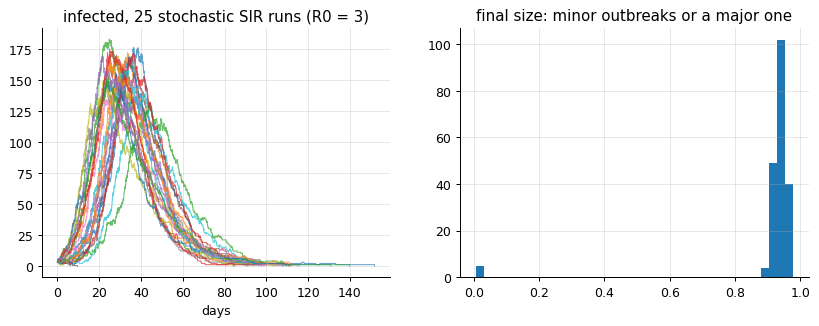

fraction of runs with a minor outbreak (< 10 % infected): 0.025; branching approximation (1/R0)^I0 = 0.037


In [5]:
s = models.sir(N=500, beta=0.3, gamma=0.1, I0=3)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
finals = []
for k in range(200):
    r = ctmc.gillespie(s["x0"], s["stoich"], s["propensity"], 300.0, R(k))
    finals.append(r["x"][-1, 2])
    if k < 25:
        ax[0].step(r["t"], r["x"][:, 1], where="post", lw=0.8, alpha=0.7)
ax[0].set_title("infected, 25 stochastic SIR runs (R0 = 3)"); ax[0].set_xlabel("days")
ax[1].hist(np.array(finals) / 500, bins=40); ax[1].set_title("final size: minor outbreaks or a major one"); plt.show()
q = (1 / 3) ** 3
print(f"fraction of runs with a minor outbreak (< 10 % infected): {np.mean(np.array(finals) < 50):.3f}; branching approximation (1/R0)^I0 = {q:.3f}")

Gillespie's direct method simulates a reaction network exactly: the time to the next event is exponential with
the total propensity, and the event is chosen in proportion to the individual propensities. The stochastic SIR
epidemic shows what the differential equations cannot: with three initial cases and R₀ = 3 about 4 % of
outbreaks die out early - the extinction probability of the branching process of notebook 8 - and the rest
infect ~94 % of the population.

exact SSA: 182537 events; protein mean 505 (theory 500), Fano factor 6.34 (theory 5.55)
tau-leaping (tau = 0.05): 30001 steps; protein mean 508, Fano 5.79


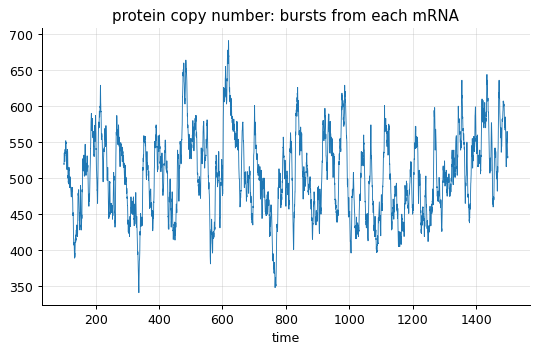

In [6]:
ge = models.gene_expression()
r = ctmc.gillespie(ge["x0"], ge["stoich"], ge["propensity"], 1500.0, R(9))
grid = np.linspace(100, 1500, 5000)
prot = ctmc.sample_path_at(r["t"], r["x"][:, 1], grid)
tl = ctmc.tau_leap(ge["x0"], ge["stoich"], ge["propensity"], 1500.0, 0.05, R(10))
print(f"exact SSA: {len(r['t'])} events; protein mean {prot.mean():.0f} (theory {ge['mean_protein']:.0f}), Fano factor {prot.var() / prot.mean():.2f} (theory {ge['fano_protein']:.2f})")
print(f"tau-leaping (tau = 0.05): {len(tl['t'])} steps; protein mean {tl['x'][2000:, 1].mean():.0f}, Fano {tl['x'][2000:, 1].var() / tl['x'][2000:, 1].mean():.2f}")
plt.plot(grid, prot, lw=0.7); plt.title("protein copy number: bursts from each mRNA"); plt.xlabel("time"); plt.show()

Two-stage gene expression produces proteins in bursts (each short-lived mRNA is translated several times), so
the protein count is far noisier than Poisson: its Fano factor is 1 + k_p/(γ_m + γ_p) ≈ 5.5 (one path of 1400 time units spans only about 140 protein
lifetimes, so the estimated variance is uncertain by ±15 %). Tau-leaping fires
Poisson numbers of each reaction over fixed steps and reproduces the statistics with a fraction of the
events, at the price of a small bias and possible negative counts when populations are small.

## Inside the algorithm: Gillespie's direct method

In [7]:
x, t, g = np.array([497, 3, 0]), 0.0, R(30)
while True:
    a = np.array([0.3 * x[0] * x[1] / 500, 0.1 * x[1]]); a0 = a.sum()
    if a0 == 0: break
    t += g.exponential(1 / a0)
    j = 0 if g.random() * a0 < a[0] else 1
    x = x + np.array([[-1, 1, 0], [0, -1, 1]])[j]
print(f"epidemic over at t = {t:.1f} days; final state S, I, R = {x.tolist()}")

epidemic over at t = 103.7 days; final state S, I, R = [33, 0, 467]


## Exercises
1. For the machine model, compute the probability that a machine that is up now is down at some point in the next 24 hours (make 'down' absorbing and use P(24)).
2. Simulate the Lotka-Volterra reaction network from `models.lotka_volterra()` many times and estimate the probability that the predators go extinct before time 50. How does it depend on the initial numbers?
3. **Implement it yourself:** write uniformisation from scratch with the truncation chosen from the Poisson tail, and reproduce `CTMC.transition_matrix` for the machine at t = 1, 10 and 100 h.